
sample = 100
Shannon Entropy  : 1.9899320546458088
Min Entropy      : 1.7369655941662063
Collision Entropy: 1.9793733494100423

sample = 500
Shannon Entropy  : 1.9985597724212474
Min Entropy      : 1.8996950942043145
Collision Entropy: 1.9970944546042442

sample = 1000
Shannon Entropy  : 1.9967817941198303
Min Entropy      : 1.9213901653036336
Collision Entropy: 1.993700539689602

sample = 5000
Shannon Entropy  : 1.9993948734319624
Min Entropy      : 1.9411986463838138
Collision Entropy: 1.9987867997650242

sample = 10000
Shannon Entropy  : 1.999700217266518
Min Entropy      : 1.964094616257872
Collision Entropy: 1.999402501751557


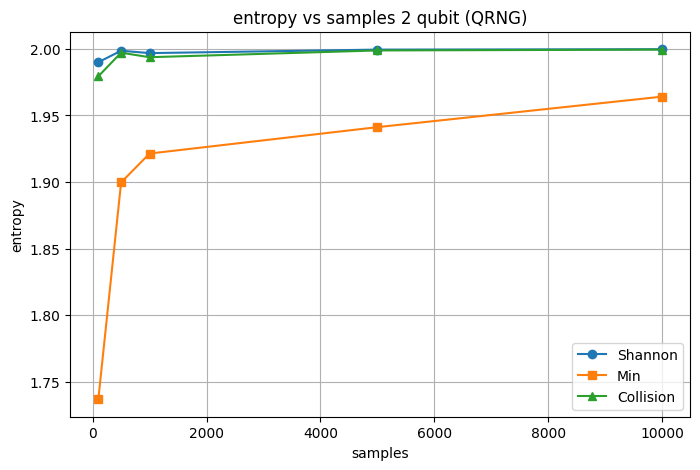

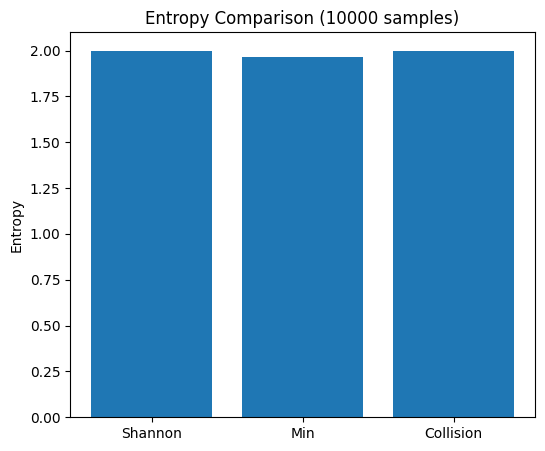

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import math
import matplotlib.pyplot as plt
from collections import Counter
# entropy 
def entropy_analysis(n):

    qc = QuantumCircuit(2)
    qc.h(0)
    qc.h(1)
    qc.measure_all()

    sim = AerSimulator()
    compiled = transpile(qc, sim)

    result = sim.run(compiled, shots=n).result()
    counts = result.get_counts()

    total = sum(counts.values())

    # probabilities
    probs = [count / total for count in counts.values()]
    bit_sequence = []
    for outcome, count in counts.items():
        bit_sequence.extend([outcome] * count)

    import random
    random.shuffle(bit_sequence)

    bit_sequence = ''.join(bit_sequence)

    # Shannon Entropy
    shannon = -sum(p * math.log2(p) for p in probs)

    # Min Entropy
    min_ent = -math.log2(max(probs))

    # Collision Entropy
    collision = -math.log2(sum(p**2 for p in probs))

    return shannon, min_ent, collision, bit_sequence


#samples
samples = [100, 500, 1000,5000,10000]

shannon_vals = []
min_vals = []
collision_vals = []

# all samples
for sample in samples:

    s, m, c, bits = entropy_analysis(sample)

    shannon_vals.append(s)
    min_vals.append(m)
    collision_vals.append(c)

    print(f"\nsample = {sample}")
    print("Shannon Entropy  :", s)
    print("Min Entropy      :", m)
    print("Collision Entropy:", c)


# graph btn samples vs entropy
plt.figure(figsize=(8,5))

plt.plot(samples, shannon_vals, marker='o', label='Shannon')
plt.plot(samples, min_vals, marker='s', label='Min')
plt.plot(samples, collision_vals, marker='^', label='Collision')

plt.xlabel("samples")
plt.ylabel("entropy")
plt.title("entropy vs samples 2 qubit (QRNG)")
plt.legend()
plt.grid()

plt.show()


# graph for comparism 
plt.figure(figsize=(6,5))

labels = ["Shannon", "Min", "Collision"]
values = [shannon_vals[-1], min_vals[-1], collision_vals[-1]]

plt.bar(labels, values)

plt.title("Entropy Comparison (10000 samples)")
plt.ylabel("Entropy")

plt.show()



In [5]:
def frequency_test(bits):
    ones = bits.count('1')
    zeros = bits.count('0')
    return ones / len(bits) * 100
print(frequency_test(bits))

49.55


In [6]:
def runs_test(bits):
    runs = 1
    for i in range(1, len(bits)):
        if bits[i] != bits[i-1]:
            runs += 1
    return runs
print(runs_test(bits))

10056


In [9]:
import numpy as np
def autocorrelation(bits, lag=1):
    n = len(bits)
    bits = np.array([1 if b=='1' else 0 for b in bits])
    
    return np.corrcoef(bits[:-lag], bits[lag:])[0,1]

print(autocorrelation(bits,lag=1))

-0.005631739344823705


In [10]:
def generate_bits(n):
    return ''.join(np.random.choice(['0','1'], n))

print(generate_bits(len(bits)))

...


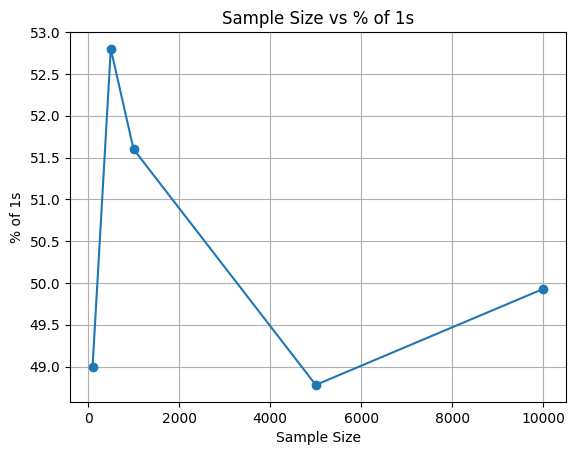

In [11]:
sizes = [100, 500, 1000, 5000, 10000]
ones_percent = []

for n in sizes:
    bits = generate_bits(n)
    ones_percent.append(frequency_test(bits))

plt.plot(sizes, ones_percent, marker='o')
plt.title("Sample Size vs % of 1s")
plt.xlabel("Sample Size")
plt.ylabel("% of 1s")
plt.grid()
plt.show()

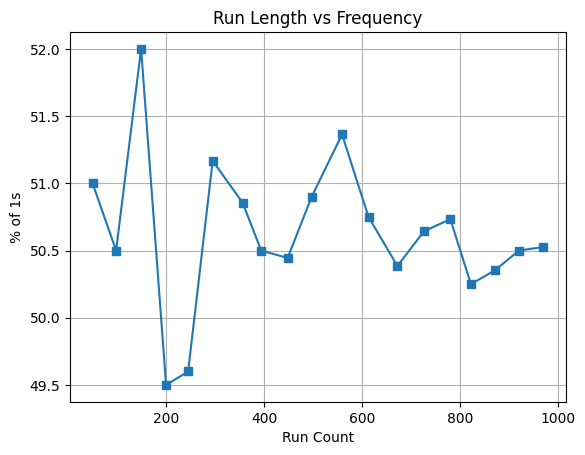

In [12]:
bits = generate_bits(5000)

run_lengths = []
freq = []

for i in range(100, 2000, 100):
    sub_bits = bits[:i]
    run_lengths.append(runs_test(sub_bits))
    freq.append(frequency_test(sub_bits))

plt.plot(run_lengths, freq, marker='s')
plt.title("Run Length vs Frequency")
plt.xlabel("Run Count")
plt.ylabel("% of 1s")
plt.grid()
plt.show()

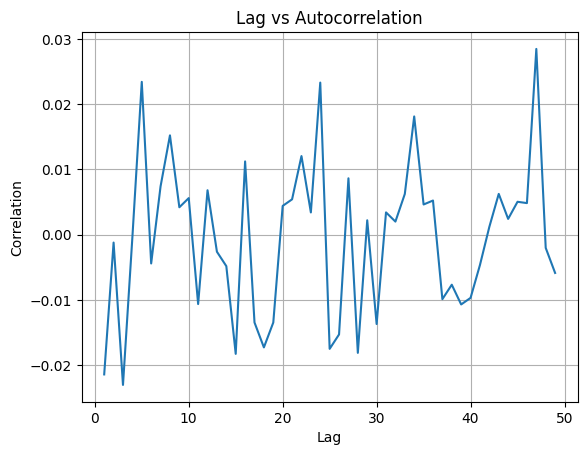

In [13]:
bits = generate_bits(5000)

lags = range(1, 50)
corrs = []

for l in lags:
    corrs.append(autocorrelation(bits, lag=l))

plt.plot(lags, corrs)
plt.title("Lag vs Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.grid()
plt.show()

In [14]:
def biased_bits(n, bias=0.7):
    return ''.join(np.random.choice(['0','1'], n, p=[1-bias, bias]))

In [16]:
def shannon_entropy(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [c/total for c in counts.values()]
    return -sum(p * math.log2(p) for p in probs)

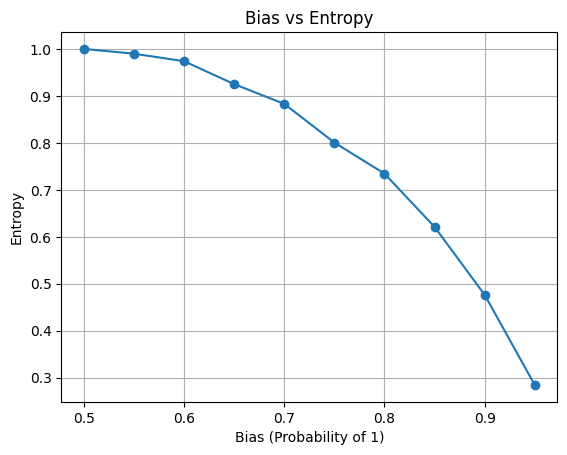

In [17]:
bias_values = np.linspace(0.5, 0.95, 10)

entropy_vals = []

for b in bias_values:
    bits = biased_bits(5000, b)
    entropy_vals.append(shannon_entropy(bits))

plt.plot(bias_values, entropy_vals, marker='o')
plt.title("Bias vs Entropy")
plt.xlabel("Bias (Probability of 1)")
plt.ylabel("Entropy")
plt.grid()
plt.show()

In [18]:
def noisy_bits(bits, noise=0.1):
    bits = list(bits)
    for i in range(len(bits)):
        if np.random.rand() < noise:
            bits[i] = '1' if bits[i]=='0' else '0'
    return ''.join(bits)

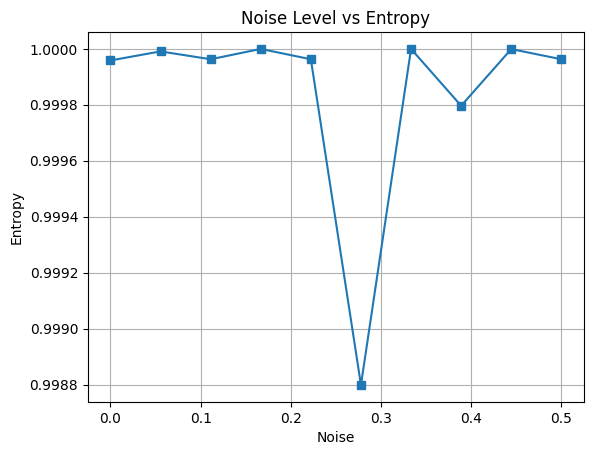

In [19]:
base_bits = generate_bits(5000)

noise_levels = np.linspace(0, 0.5, 10)
entropy_vals = []

for n in noise_levels:
    noisy = noisy_bits(base_bits, n)
    entropy_vals.append(shannon_entropy(noisy))

plt.plot(noise_levels, entropy_vals, marker='s')
plt.title("Noise Level vs Entropy")
plt.xlabel("Noise")
plt.ylabel("Entropy")
plt.grid()
plt.show()

In [20]:
def drift_bits(n):
    bits = []
    for t in range(n):
        bias = 0.5 + (t / n) * 0.4   # slowly increases bias
        bit = np.random.choice(['0','1'], p=[1-bias, bias])
        bits.append(bit)
    return ''.join(bits)

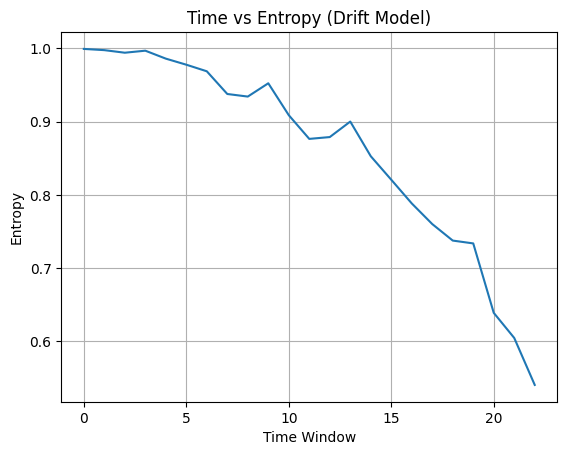

In [21]:
entropy_over_time = []
window = 500

bits = drift_bits(5000)

for i in range(0, 5000-window, 200):
    segment = bits[i:i+window]
    entropy_over_time.append(shannon_entropy(segment))

plt.plot(entropy_over_time)
plt.title("Time vs Entropy (Drift Model)")
plt.xlabel("Time Window")
plt.ylabel("Entropy")
plt.grid()
plt.show()